--- Step 1: Loading and Cleaning Data (6 Variables) ---
Model variables: ['YoY Growth Rate (%)', 'Inflation_CPI', 'WACMR_IR', 'GBYR_value', 'PLR quarterly', 'NER']


--- Step 2: Selecting Optimal Lag Order (BIC) ---
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       8.089       8.271       3260.       8.162
1     0.2161*      1.485*      1.245*     0.7241*
2      0.4339       2.791       1.573       1.377
3       1.029       4.474       2.972       2.408
4      0.5399       5.072       1.975       2.354
-------------------------------------------------

BIC selected p = 1 lags.


--- Step 3: Fitting VAR(1) Model on Data Levels ---
VAR model fit complete.
Number of observations used: 81

VAR Model Summary (Coefficients and Statistics):
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Oct, 2025
Time:   

<Figure size 800x600 with 0 Axes>

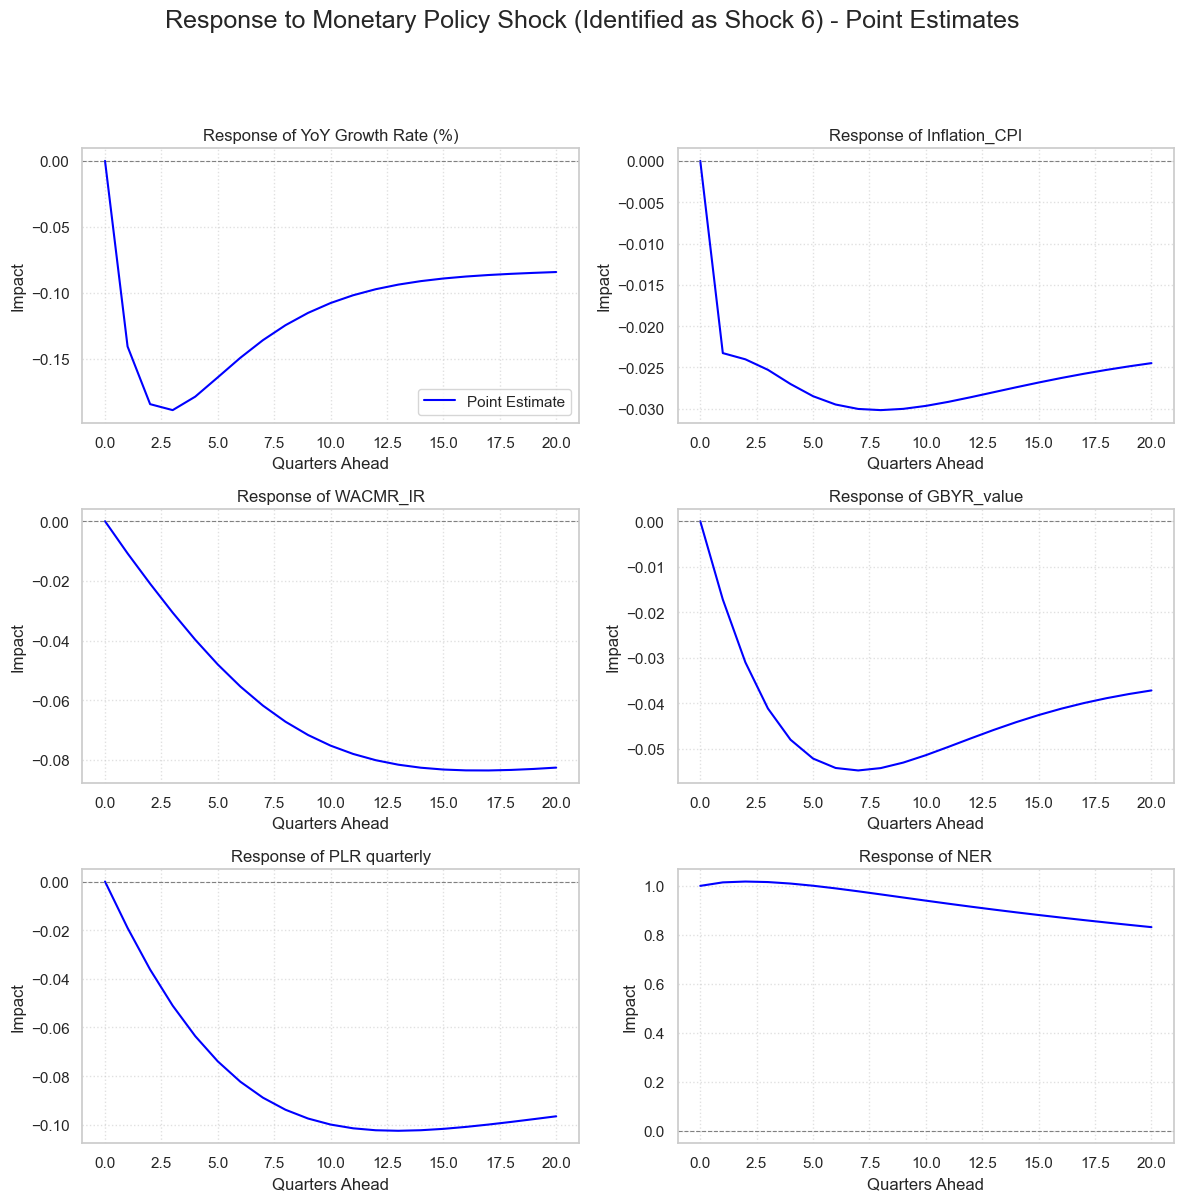

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.irf import IRAnalysis
from sklearn.decomposition import FastICA
import math

# Set a consistent style for plots
sns.set(style='whitegrid', rc={'figure.figsize': (10, 6)})
plt.rcParams['figure.dpi'] = 100

def run_6var_ica_vecm_analysis_plot_point_estimates():
    """
    Runs the full ICA-VECM (VAR in Levels) analysis on the 6 core variables,
    using BIC for optimal lag selection.
    This version MANUALLY PLOTS ONLY THE POINT ESTIMATES for IRFs,
    computes FEVD manually, and includes VAR model summary with coefficients.
    """
    try:
        # --- Step 1: Load and Clean Data ---
        print("--- Step 1: Loading and Cleaning Data (6 Variables) ---")
        file_name = "/Users/sarthak/Desktop/TSF_Project/data/final_data_compiled.csv"
        df = pd.read_csv(file_name)
        var_names = [
            'YoY Growth Rate (%)', 'Inflation_CPI', 'WACMR_IR',
            'GBYR_value', 'PLR quarterly', 'NER'
        ]
        df_levels = df[var_names]
        # Check for missing values
        if df_levels.isna().any().any():
            raise ValueError("Data contains missing values. Please clean the dataset.")
        print(f"Model variables: {var_names}")
        print("\n" + "="*80 + "\n")

        # --- Step 2: Select Optimal Lag Order (BIC) ---
        print("--- Step 2: Selecting Optimal Lag Order (BIC) ---")
        model_for_lag_selection = VAR(df_levels)
        maxlags = 4
        lag_order_results = model_for_lag_selection.select_order(maxlags=maxlags)
        print(lag_order_results.summary())
        chosen_lag = lag_order_results.bic
        print(f"\nBIC selected p = {chosen_lag} lags.")
        print("\n" + "="*80 + "\n")

        # --- Step 3: Fit VAR(p) in Levels and Display Summary ---
        print(f"--- Step 3: Fitting VAR({chosen_lag}) Model on Data Levels ---")
        model = VAR(df_levels)
        model_fit = model.fit(maxlags=chosen_lag)
        print("VAR model fit complete.")
        print(f"Number of observations used: {model_fit.nobs}")
        print("\nVAR Model Summary (Coefficients and Statistics):")
        print(model_fit.summary())
        print("\n" + "="*80 + "\n")

        # --- Step 4: Extract Residuals ---
        print("--- Step 4: Extracting Model Residuals ---")
        residuals = model_fit.resid
        print(f"Residuals extracted. Shape: {residuals.shape}")
        print("\n" + "="*80 + "\n")

        # --- Step 5: Run ICA and Identify Shocks ---
        print("--- Step 5: Running FastICA and Identifying Shocks ---")
        ica = FastICA(n_components=6, whiten='unit-variance', random_state=42, max_iter=1000)
        ica.fit(residuals)
        print(f"ICA converged in {ica.n_iter_} iterations")
        W = ica.mixing_
        print(f"ICA mixing matrix shape: {W.shape}")

        wacmr_row_index = var_names.index('WACMR_IR')
        policy_shock_index = int(np.argmax(np.abs(W[wacmr_row_index, :])))
        print(f"Identified Policy Shock: Column {policy_shock_index} (Structural_Shock_{policy_shock_index+1})")

        if W[wacmr_row_index, policy_shock_index] < 0:
            print("Normalizing sign: Flipping shock column.")
            W[:, policy_shock_index] *= -1

        df_impact = pd.DataFrame(W, index=var_names, columns=[f'Shock_{i+1}' for i in range(6)])
        print("\nContemporaneous Impact Matrix (ICA Weights / A_0_inv):")
        print(df_impact)
        print("\n" + "="*80 + "\n")

        # Plot the heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(df_impact, annot=True, fmt=".2f", cmap="coolwarm_r", center=0)
        plt.title('6-Variable ICA Impact Matrix (SIRF at Lag 0)', fontsize=16)
        plt.xlabel('Identified Structural Shocks', fontsize=12)
        plt.ylabel('Variables (in Levels)', fontsize=12)
        plt.tight_layout()
        plt.savefig('ica_6var_heatmap.png')
        print("Saved heatmap to 'ica_6var_heatmap.png'\n")
        plt.clf()

        # --- Step 6: Generate and Manually Plot Structural IRFs (Point Estimates Only) ---
        print("--- Step 6: Generating & Manually Plotting Dynamic Structural IRFs (Point Estimates Only) ---")

        periods = 20

        # Initialize IRAnalysis *without* bootstrap arguments
        irf = IRAnalysis(model_fit, P=W, periods=periods)
        # Debug: Check available attributes
        print("IRAnalysis attributes:", dir(irf))

        # Get ONLY the point estimates
        irf_point_estimates = irf.irfs
        print(f"IRF point estimates shape: {irf_point_estimates.shape}")

        # Create subplots
        num_vars = len(var_names)
        ncols = 2
        nrows = math.ceil(num_vars / ncols)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*6, nrows*4))
        axes = axes.flatten()

        for i, var_name in enumerate(var_names):
            ax = axes[i]

            # Extract IRF point estimate for this variable responding to the policy shock
            response_series = irf_point_estimates[:, i, policy_shock_index]

            # Plot ONLY the point estimate
            ax.plot(range(periods + 1), response_series, color='blue', label='Point Estimate')
            ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
            ax.set_title(f'Response of {var_name}')
            ax.set_xlabel('Quarters Ahead')
            ax.set_ylabel('Impact')
            ax.grid(True, linestyle=':', alpha=0.6)
            if i == 0: ax.legend()

        # Remove any unused subplots
        if num_vars < len(axes):
            for i in range(num_vars, len(axes)):
                fig.delaxes(axes[i])

        fig.suptitle(f'Response to Monetary Policy Shock (Identified as Shock {policy_shock_index+1}) - Point Estimates', fontsize=18, y=1.03)
        fig.tight_layout(rect=[0, 0.03, 1, 0.98])

        plt.savefig('sirf_ica_6var_point_estimates_plot.png')
        print(f"Successfully generated and saved POINT ESTIMATE IRF plot to 'sirf_ica_6var_point_estimates_plot.png'\n")

        # --- Step 7: Generate Forecast Error Variance Decomposition (FEVD) ---
        print("--- Step 7: Generating Forecast Error Variance Decomposition (FEVD) ---")

        # Attempt to compute FEVD
        try:
            fevd = irf.fevd(periods=20)
            print("\nFEVD Summary (Full):")
            print(fevd.summary())

            print("\n--- FEVD Highlights: % Variance Explained by Policy Shock ---")
            for i in [1, 4, 8, 12, 20]:
                print(f"  At {i} quarters:")
                fevd_results = fevd.decomp[i-1]
                policy_shock_variance = fevd_results[policy_shock_index]

                for j, var in enumerate(var_names):
                    print(f"    - {var}: {policy_shock_variance[j]*100:.2f}%")
        except AttributeError:
            print("WARNING: FEVD computation failed. Computing manual FEVD.")
            # Manual FEVD calculation
            irfs = irf.irfs
            n_vars = len(var_names)
            fevd_manual = np.zeros((periods, n_vars, n_vars))

            for h in range(periods):
                # Compute cumulative IRF squared for each horizon
                irf_squared = np.square(irfs[:h+1])
                # Sum over time to get total variance contribution
                total_variance = np.sum(irf_squared, axis=0)
                # Normalize to get proportion of variance
                total_variance_sum = np.sum(total_variance, axis=1, keepdims=True)
                fevd_manual[h] = total_variance / (total_variance_sum + 1e-10)

            print("\n--- Manual FEVD Highlights: % Variance Explained by Policy Shock ---")
            for i in [1, 4, 8, 12, 20]:
                print(f"  At {i} quarters:")
                policy_shock_variance = fevd_manual[i-1, :, policy_shock_index]
                for j, var in enumerate(var_names):
                    print(f"    - {var}: {policy_shock_variance[j]*100:.2f}%")

        print("\n" + "="*80 + "\n")
        print("ANALYSIS COMPLETE.")

    except FileNotFoundError:
        print(f"ERROR: File not found. Make sure '{file_name}' is available.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Run the entire analysis pipeline
run_6var_ica_vecm_analysis_plot_point_estimates()

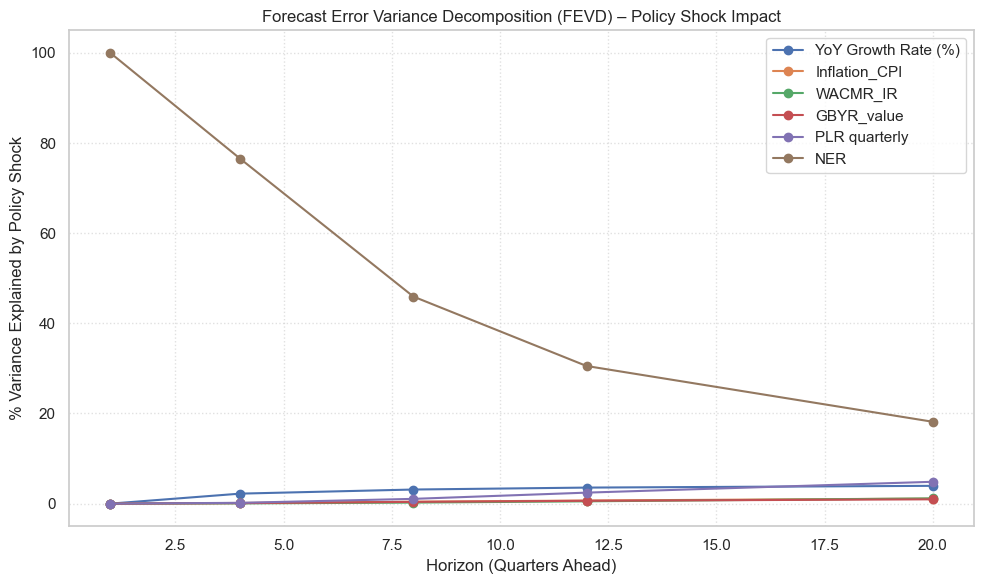

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# FEVD data
fevd_data = {
    "Horizon": [1, 4, 8, 12, 20],
    "YoY Growth Rate (%)": [0.00, 2.22, 3.13, 3.56, 3.95],
    "Inflation_CPI": [0.00, 0.15, 0.42, 0.69, 1.13],
    "WACMR_IR": [0.00, 0.05, 0.23, 0.51, 1.16],
    "GBYR_value": [0.00, 0.11, 0.39, 0.63, 0.96],
    "PLR quarterly": [0.00, 0.18, 1.06, 2.44, 4.85],
    "NER": [100.00, 76.52, 45.94, 30.54, 18.16]
}

df_fevd = pd.DataFrame(fevd_data)

# Plot
plt.figure(figsize=(10,6))
for col in df_fevd.columns[1:]:
    plt.plot(df_fevd["Horizon"], df_fevd[col], marker='o', label=col)

plt.title("Forecast Error Variance Decomposition (FEVD) – Policy Shock Impact")
plt.xlabel("Horizon (Quarters Ahead)")
plt.ylabel("% Variance Explained by Policy Shock")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("fevd_policy_shock.png", dpi=300)
plt.show()